# Step 1

In this step, all required libraries are imported, professional chart styling is configured, folders are created, the dataset is loaded, and initial inspection is performed.


In [2]:
print("="*60)
print("Step 1: Environment setup and dataset loading")
print("="*60)


Step 1: Environment setup and dataset loading


In [3]:
from pathlib import Path
from io import StringIO
from typing import List, Tuple, Dict, Optional, Any
import zipfile
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

warnings.filterwarnings("ignore")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#F8FAFC"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

sns.set_theme(style="whitegrid")


In [4]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

for folder in [DATA_RAW, DATA_PROCESSED, FIGURES_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")
print("Project root:", PROJECT_ROOT)


Project folders are ready.
Project root: d:\AIML-Internship-Week3-IjazAhmad


In [5]:
train_path = DATA_RAW / "train.csv"

if not train_path.exists():
    zip_candidates = [
        PROJECT_ROOT / "house-prices-advanced-regression-techniques.zip",
        DATA_RAW / "house-prices-advanced-regression-techniques.zip"
    ]

    zip_file = None
    for path in zip_candidates:
        if path.exists():
            zip_file = path
            break

    if zip_file is not None:
        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(DATA_RAW)
        print("Dataset extracted successfully.")
    else:
        print("Dataset zip not found. Place the zip file in project root or data/raw folder.")
else:
    print("train.csv already exists in data/raw.")


train.csv already exists in data/raw.


In [6]:
df = pd.read_csv(DATA_RAW / "train.csv")

print("="*60)
print("Dataset loaded successfully")
print("="*60)
print("Dataset shape:", df.shape)


Dataset loaded successfully
Dataset shape: (1460, 81)


In [7]:
buffer = StringIO()
df.info(buf=buffer)
info_text = buffer.getvalue()

print("="*60)
print("Dataset info")
print("="*60)
print(info_text)

print("="*60)
print("Dataset statistical summary")
print("="*60)
display(df.describe())


Dataset info
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overal

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [8]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("="*60)
print("Numerical and categorical columns")
print("="*60)
print("Total numerical columns:", len(numerical_cols))
print("Total categorical columns:", len(categorical_cols))
print("\nNumerical columns:")
print(numerical_cols)
print("\nCategorical columns:")
print(categorical_cols)


Numerical and categorical columns
Total numerical columns: 38
Total categorical columns: 43

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2

In [9]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
top10_corr = numeric_df.corr()["SalePrice"].abs().sort_values(ascending=False).head(10)

print("="*60)
print("Top 10 correlated features with SalePrice")
print("="*60)
print(top10_corr)


Top 10 correlated features with SalePrice
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


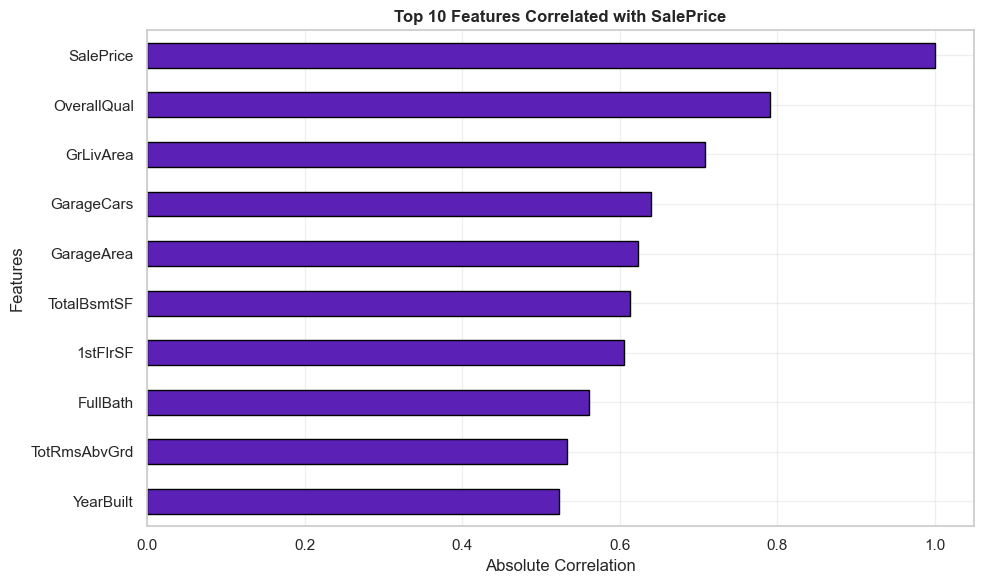

Step 1 reports and figure saved.


In [10]:
df.describe().to_csv(REPORTS_DIR / "step1_describe_summary.csv")
pd.DataFrame({"numerical_columns": numerical_cols}).to_csv(REPORTS_DIR / "step1_numerical_columns.csv", index=False)
pd.DataFrame({"categorical_columns": categorical_cols}).to_csv(REPORTS_DIR / "step1_categorical_columns.csv", index=False)
top10_corr.to_csv(REPORTS_DIR / "step1_top10_correlated_features.csv")

summary_text = f'''
Step 1 — Environment Setup and Dataset Loading

Dataset Shape:
{df.shape}

Total Numerical Columns:
{len(numerical_cols)}

Total Categorical Columns:
{len(categorical_cols)}

Dataset Info:
{info_text}

Top 10 Correlated Features with SalePrice:
{top10_corr}
'''

with open(REPORTS_DIR / "step1_dataset_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

plt.figure(figsize=(10, 6))
top10_corr.sort_values().plot(kind="barh", color="#5B21B6", edgecolor="black")
plt.title("Top 10 Features Correlated with SalePrice", fontweight="bold")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step1_top10_correlations.png", dpi=150)
plt.show()

print("Step 1 reports and figure saved.")


### Step 1 Summary

The dataset was loaded successfully and inspected using shape, info, and descriptive statistics. Numerical and categorical columns were separated because they require different preprocessing methods. The top 10 features most correlated with `SalePrice` were calculated to guide later feature engineering and visualization.


# Step 2

This step creates SalePrice distribution charts before and after log transformation, plus box and violin plots for `GrLivArea`.


In [11]:
print("="*60)
print("Step 2: Matplotlib chart 1 and 2 - distribution analysis")
print("="*60)


Step 2: Matplotlib chart 1 and 2 - distribution analysis


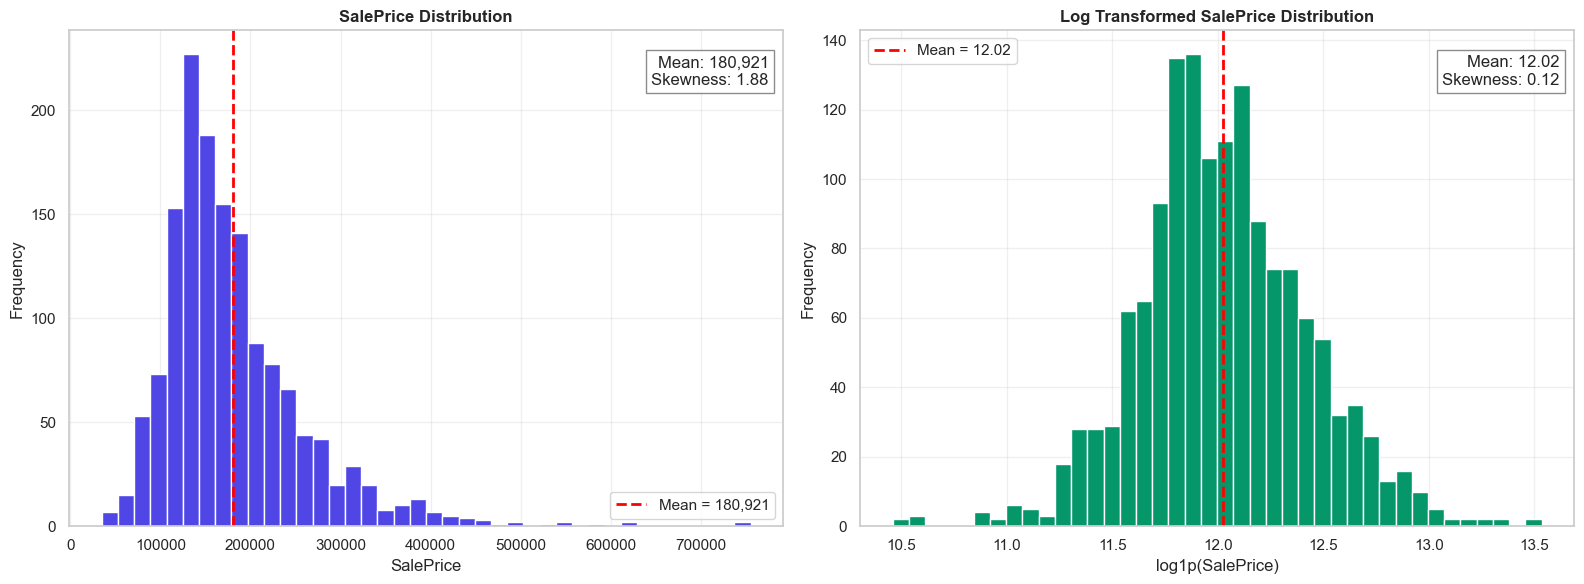

In [12]:
saleprice_mean = df["SalePrice"].mean()
saleprice_skew = df["SalePrice"].skew()
log_saleprice = np.log1p(df["SalePrice"])
log_saleprice_mean = log_saleprice.mean()
log_saleprice_skew = log_saleprice.skew()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df["SalePrice"], bins=40, color="#4F46E5", edgecolor="white")
axes[0].axvline(saleprice_mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {saleprice_mean:,.0f}")
axes[0].set_title("SalePrice Distribution", fontweight="bold")
axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].text(0.98, 0.95, f"Mean: {saleprice_mean:,.0f}\nSkewness: {saleprice_skew:.2f}",
             transform=axes[0].transAxes, ha="right", va="top",
             bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9))

axes[1].hist(log_saleprice, bins=40, color="#059669", edgecolor="white")
axes[1].axvline(log_saleprice_mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {log_saleprice_mean:.2f}")
axes[1].set_title("Log Transformed SalePrice Distribution", fontweight="bold")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].text(0.98, 0.95, f"Mean: {log_saleprice_mean:.2f}\nSkewness: {log_saleprice_skew:.2f}",
             transform=axes[1].transAxes, ha="right", va="top",
             bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "step2_saleprice_distribution.png", dpi=150)
plt.show()


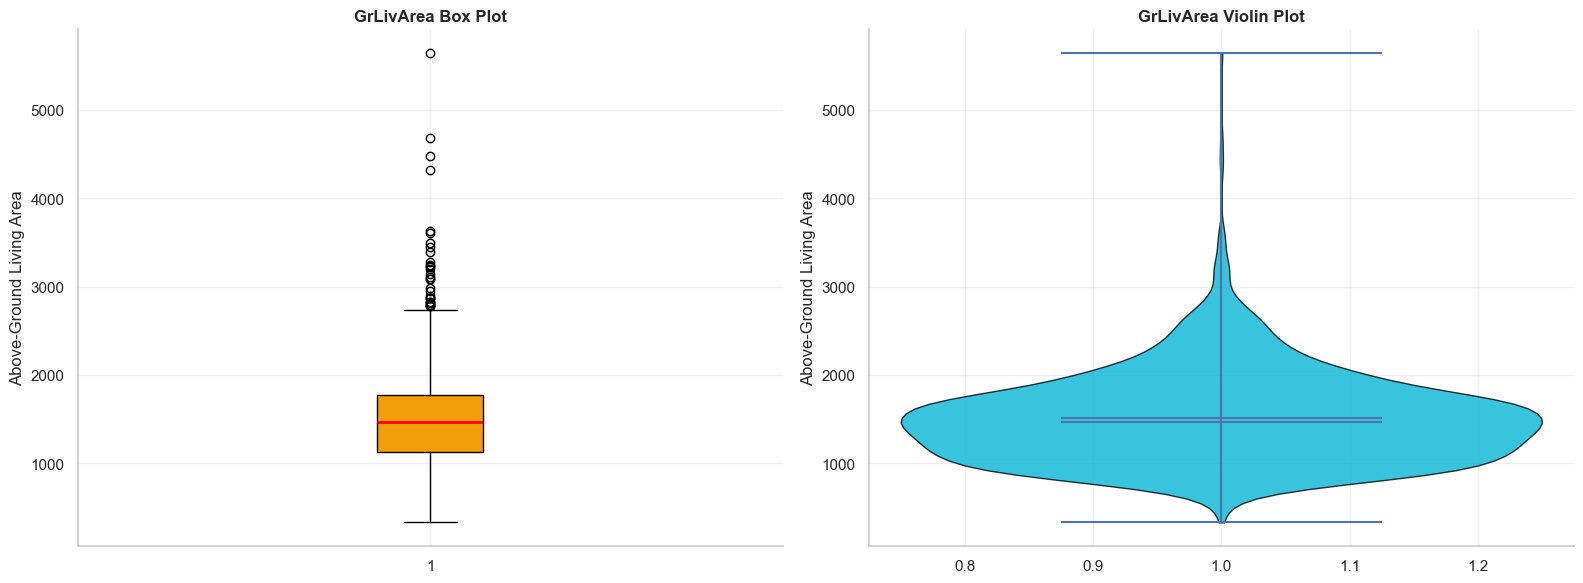

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].boxplot(
    df["GrLivArea"].dropna(),
    patch_artist=True,
    boxprops=dict(facecolor="#F59E0B", color="black"),
    medianprops=dict(color="red", linewidth=2)
)
axes[0].set_title("GrLivArea Box Plot", fontweight="bold")
axes[0].set_ylabel("Above-Ground Living Area")

parts = axes[1].violinplot(df["GrLivArea"].dropna(), showmeans=True, showmedians=True)
for body in parts["bodies"]:
    body.set_facecolor("#06B6D4")
    body.set_edgecolor("black")
    body.set_alpha(0.8)

axes[1].set_title("GrLivArea Violin Plot", fontweight="bold")
axes[1].set_ylabel("Above-Ground Living Area")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "step2_grlivarea_distribution.png", dpi=150)
plt.show()


In [14]:
step2_summary = f'''
Step 2 — Distribution Analysis

SalePrice Mean: {saleprice_mean:,.2f}
SalePrice Skewness: {saleprice_skew:.4f}
Log1p(SalePrice) Mean: {log_saleprice_mean:.4f}
Log1p(SalePrice) Skewness: {log_saleprice_skew:.4f}
GrLivArea Mean: {df['GrLivArea'].mean():,.2f}
GrLivArea Median: {df['GrLivArea'].median():,.2f}
GrLivArea Skewness: {df['GrLivArea'].skew():.4f}
'''

with open(REPORTS_DIR / "step2_distribution_summary.txt", "w", encoding="utf-8") as f:
    f.write(step2_summary)

print("Step 2 report saved.")


Step 2 report saved.


**Summary**

The original `SalePrice` distribution is right-skewed, while log transformation makes it more balanced. The `GrLivArea` box plot and violin plot show distribution spread, density, and possible outliers.


## Step 3

This chart encodes four variables: `GrLivArea`, `SalePrice`, `OverallQual`, and `GarageCars`.


In [15]:
print("="*60)
print("Step 3: Multi-variable scatter plot")
print("="*60)


Step 3: Multi-variable scatter plot


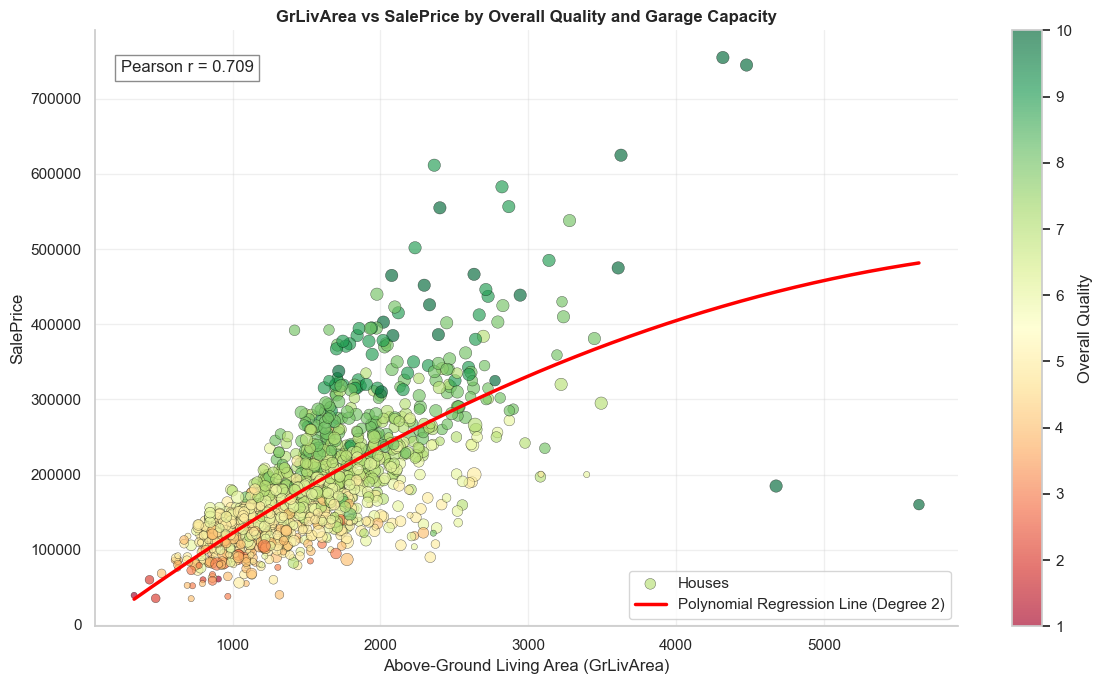

In [16]:
x = df["GrLivArea"]
y = df["SalePrice"]
color_values = df["OverallQual"]
point_sizes = 20 + (df["GarageCars"].fillna(0) * 20)
pearson_corr = df["GrLivArea"].corr(df["SalePrice"])

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    x, y,
    c=color_values,
    cmap=plt.cm.RdYlGn,
    s=point_sizes,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.3,
    label="Houses"
)

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Overall Quality")

poly_coefficients = np.polyfit(x, y, deg=2)
poly_function = np.poly1d(poly_coefficients)
x_sorted = np.linspace(x.min(), x.max(), 300)
y_pred = poly_function(x_sorted)

ax.plot(x_sorted, y_pred, color="red", linewidth=2.5, label="Polynomial Regression Line (Degree 2)")

ax.set_title("GrLivArea vs SalePrice by Overall Quality and Garage Capacity", fontweight="bold")
ax.set_xlabel("Above-Ground Living Area (GrLivArea)")
ax.set_ylabel("SalePrice")

ax.text(0.03, 0.95, f"Pearson r = {pearson_corr:.3f}", transform=ax.transAxes,
        fontsize=12, va="top", bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "step3_multivariable_scatter.png", dpi=150)
plt.show()


In [17]:
step3_summary = f'''
Step 3 — Multi-Variable Scatter Plot

Variables encoded:
1. GrLivArea on x-axis
2. SalePrice on y-axis
3. OverallQual using color
4. GarageCars using point size

Pearson Correlation:
{pearson_corr:.4f}
'''

with open(REPORTS_DIR / "step3_multivariable_scatter_summary.txt", "w", encoding="utf-8") as f:
    f.write(step3_summary)

print("Step 3 report saved.")


Step 3 report saved.


**Summary**

The scatter plot shows that houses with larger living areas and higher overall quality generally have higher sale prices. Garage capacity is shown through point size, while a polynomial regression line highlights the trend.


# Step 4

This step groups `YearBuilt` into decades and compares house count and average sale price by construction decade.


In [18]:
print("="*60)
print("Step 4: Time-based trend analysis")
print("="*60)


Step 4: Time-based trend analysis


In [19]:
df["YearBuilt_Decade"] = (df["YearBuilt"] // 10) * 10
df["YearBuilt_Decade_Label"] = df["YearBuilt_Decade"].astype(str) + "s"

houses_per_decade = df.groupby("YearBuilt_Decade")["Id"].count()
avg_price_decade = df.groupby("YearBuilt_Decade")["SalePrice"].mean()

print("Houses per decade:")
print(houses_per_decade)
print("\nAverage SalePrice by decade:")
print(avg_price_decade)


Houses per decade:
YearBuilt_Decade
1870      2
1880      7
1890      6
1900     15
1910     58
1920     97
1930     54
1940     79
1950    167
1960    175
1970    188
1980     61
1990    163
2000    387
2010      1
Name: Id, dtype: int64

Average SalePrice by decade:
YearBuilt_Decade
1870    108000.000000
1880    170425.571429
1890    216316.666667
1900    129828.400000
1910    131511.482759
1920    123268.350515
1930    144415.833333
1940    126887.481013
1950    140935.670659
1960    153852.640000
1970    152828.335106
1980    190080.327869
1990    228404.220859
2000    242046.416021
2010    394432.000000
Name: SalePrice, dtype: float64


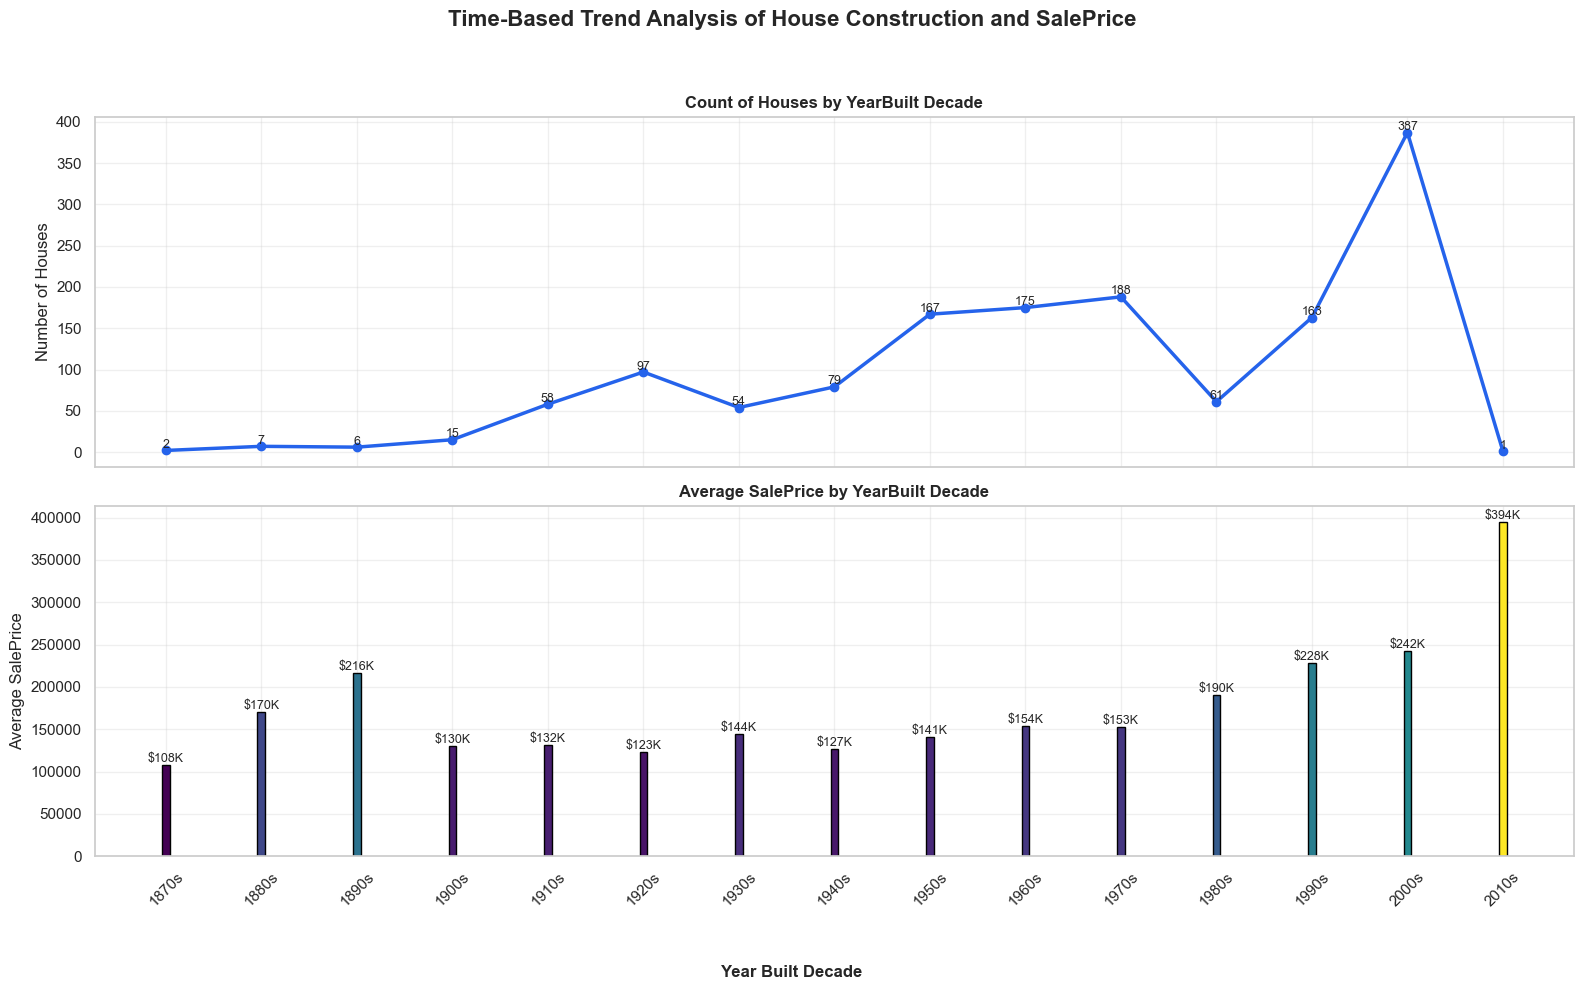

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].plot(houses_per_decade.index, houses_per_decade.values, marker="o", color="#2563EB", linewidth=2.5)
axes[0].set_title("Count of Houses by YearBuilt Decade", fontweight="bold")
axes[0].set_ylabel("Number of Houses")

for x, y in zip(houses_per_decade.index, houses_per_decade.values):
    axes[0].text(x, y + 3, str(y), ha="center", fontsize=9)

norm = plt.Normalize(avg_price_decade.min(), avg_price_decade.max())
colors = plt.cm.viridis(norm(avg_price_decade.values))

bars = axes[1].bar(avg_price_decade.index, avg_price_decade.values, color=colors, edgecolor="black")
axes[1].set_title("Average SalePrice by YearBuilt Decade", fontweight="bold")
axes[1].set_ylabel("Average SalePrice")

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height, f"${height/1000:.0f}K",
                 ha="center", va="bottom", fontsize=9)

decade_labels = [str(int(decade)) + "s" for decade in houses_per_decade.index]
axes[1].set_xticks(houses_per_decade.index)
axes[1].set_xticklabels(decade_labels, rotation=45)

fig.supxlabel("Year Built Decade", fontsize=12, fontweight="bold")
fig.suptitle("Time-Based Trend Analysis of House Construction and SalePrice", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(FIGURES_DIR / "w3_time_trend.png", dpi=150)
plt.show()


In [21]:
step4_summary = f'''
Step 4 — Time-Based Trend Analysis

Houses Per Decade:
{houses_per_decade}

Average SalePrice by Decade:
{avg_price_decade}
'''

with open(REPORTS_DIR / "step4_time_trend_summary.txt", "w", encoding="utf-8") as f:
    f.write(step4_summary)

print("Step 4 report saved.")


Step 4 report saved.


**Summary**

The count chart shows construction activity by decade, while the average sale price chart shows how construction age relates to house price. Newer houses generally tend to have higher average prices.


# Step 5

This step creates a neighborhood boxplot and correlation heatmap.


In [22]:
print("="*60)
print("Step 5: Seaborn charts 5 and 6 - statistical visualization")
print("="*60)


Step 5: Seaborn charts 5 and 6 - statistical visualization


In [23]:
top8_neighborhoods = df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).head(8)
top8_names = top8_neighborhoods.index.tolist()

df_top8 = df[df["Neighborhood"].isin(top8_names)].copy()
df_top8["Neighborhood"] = pd.Categorical(df_top8["Neighborhood"], categories=top8_names, ordered=True)

overall_mean_price = df_top8["SalePrice"].mean()

print("Top 8 neighborhoods by median SalePrice:")
print(top8_neighborhoods)


Top 8 neighborhoods by median SalePrice:
Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
Name: SalePrice, dtype: float64


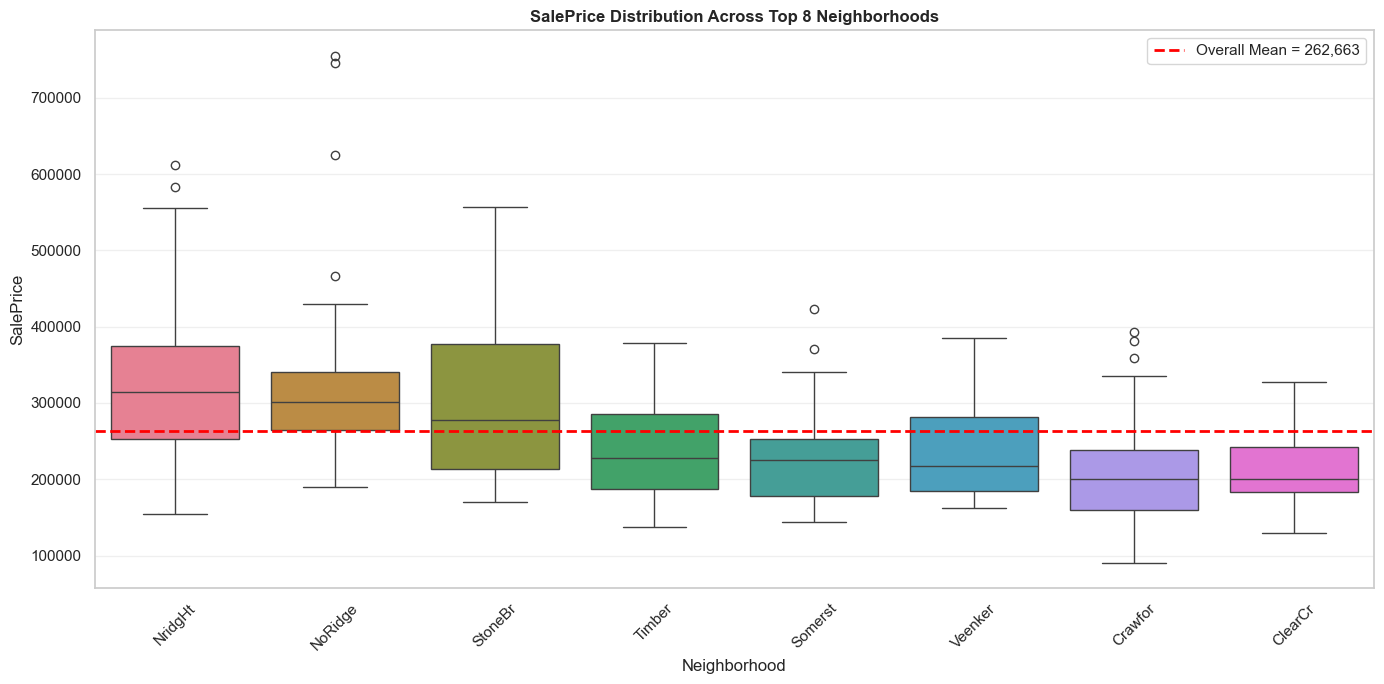

In [24]:
plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=df_top8,
    x="Neighborhood",
    y="SalePrice",
    palette=sns.color_palette("husl", 8)
)

ax.axhline(overall_mean_price, color="red", linestyle="--", linewidth=2,
           label=f"Overall Mean = {overall_mean_price:,.0f}")

ax.set_title("SalePrice Distribution Across Top 8 Neighborhoods", fontweight="bold")
ax.set_xlabel("Neighborhood")
ax.set_ylabel("SalePrice")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step5_neighborhood_boxplot.png", dpi=150)
plt.show()


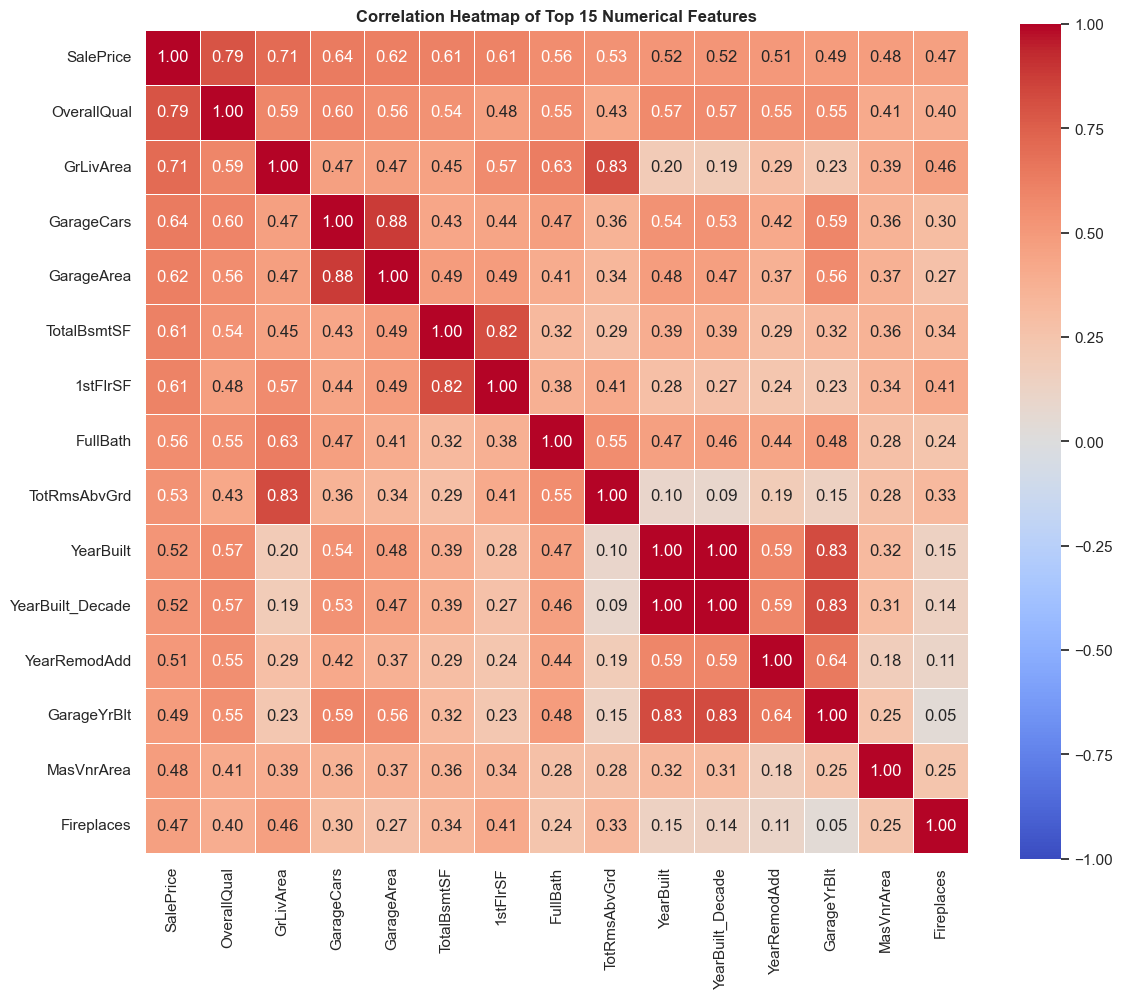

Top 15 features:
['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearBuilt_Decade', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea', 'Fireplaces']


In [25]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

top15_features = numeric_df.corr()["SalePrice"].abs().sort_values(ascending=False).head(15).index.tolist()
top15_corr_matrix = numeric_df[top15_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top15_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)

plt.title("Correlation Heatmap of Top 15 Numerical Features", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step5_top15_corr_heatmap.png", dpi=150)
plt.show()

print("Top 15 features:")
print(top15_features)


In [26]:
step5_summary = f'''
Step 5 — Statistical Visualization

Top 8 Neighborhoods:
{top8_neighborhoods}

Top 15 Features:
{top15_features}
'''

with open(REPORTS_DIR / "step5_statistical_visualization_summary.txt", "w", encoding="utf-8") as f:
    f.write(step5_summary)

top8_neighborhoods.to_csv(REPORTS_DIR / "step5_top8_neighborhoods.csv")
pd.DataFrame({"Top15_Features": top15_features}).to_csv(REPORTS_DIR / "step5_top15_features.csv", index=False)

print("Step 5 report saved.")


Step 5 report saved.


**Summary**

The boxplot compares `SalePrice` across the most expensive neighborhoods. The heatmap highlights numerical features strongly related to `SalePrice` and helps detect possible multicollinearity.


# Step 6
This step creates a pair plot and FacetGrid.


In [27]:
print("="*60)
print("Step 6: Seaborn advanced - FacetGrid and Pair Plot")
print("="*60)


Step 6: Seaborn advanced - FacetGrid and Pair Plot


In [28]:
df["OverallQual_Bin"] = pd.cut(
    df["OverallQual"],
    bins=[0, 4, 7, 10],
    labels=["Low", "Medium", "High"]
)

print("OverallQual_Bin value counts:")
print(df["OverallQual_Bin"].value_counts())


OverallQual_Bin value counts:
OverallQual_Bin
Medium    1090
High       229
Low        141
Name: count, dtype: int64


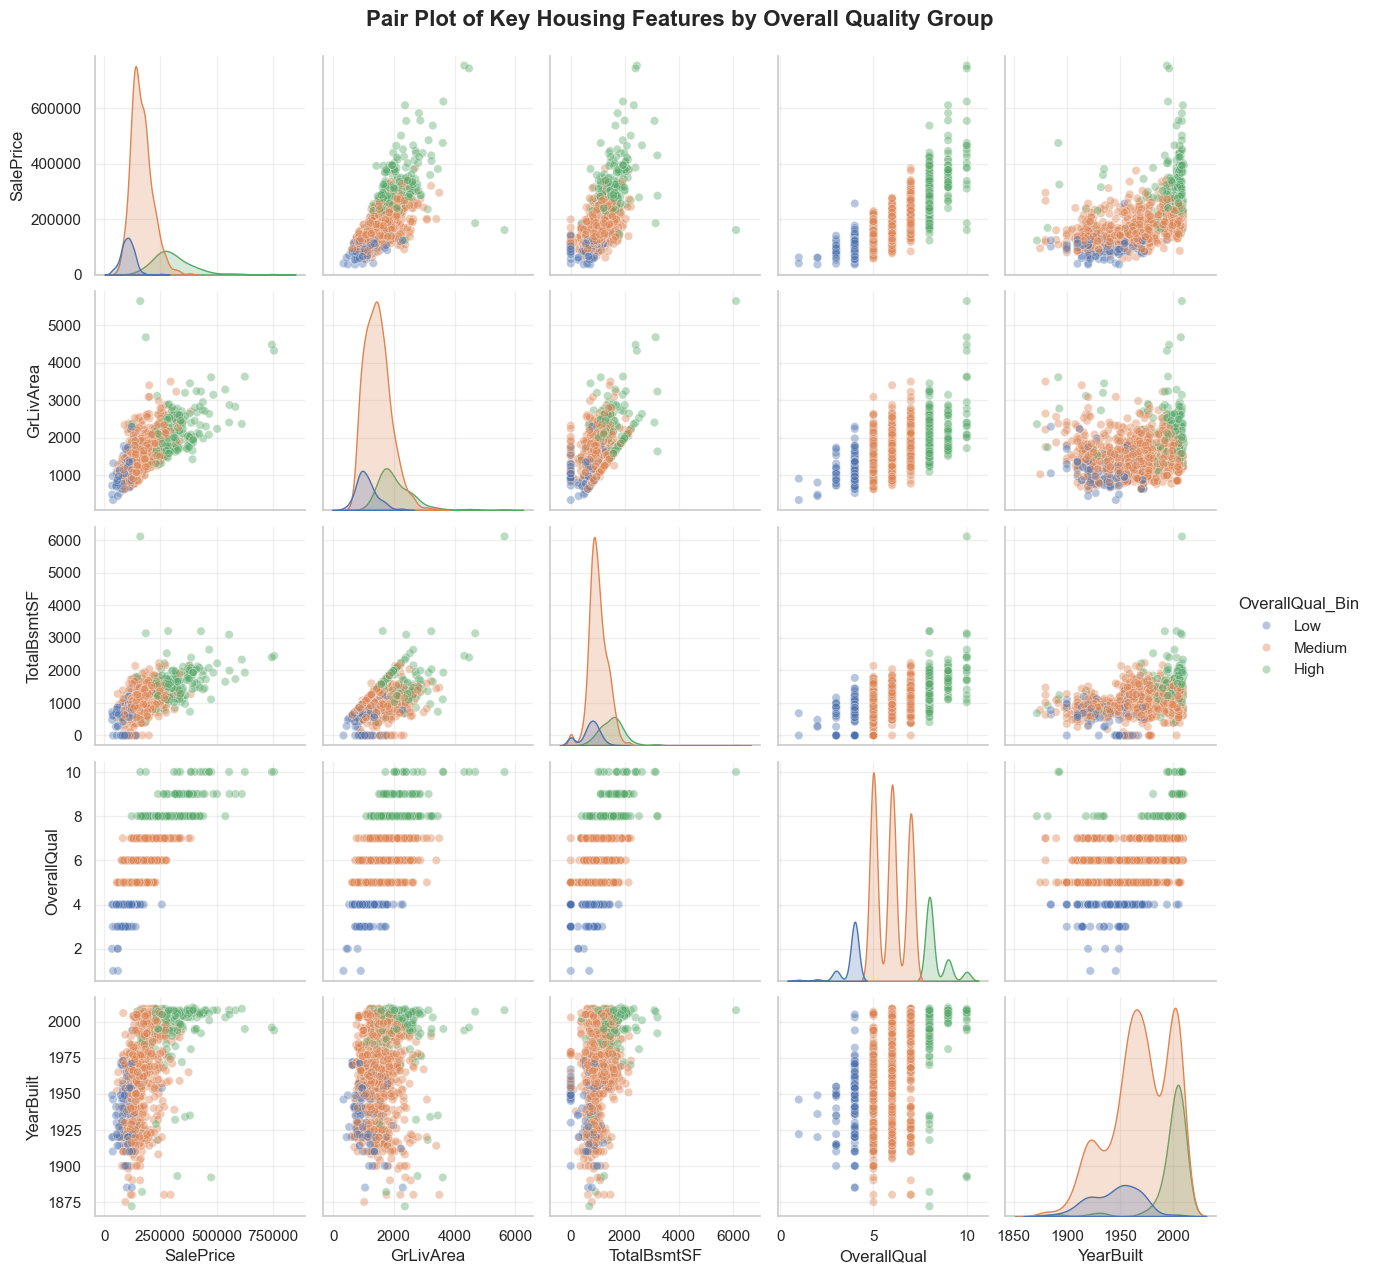

In [29]:
pairplot_cols = ["SalePrice", "GrLivArea", "TotalBsmtSF", "OverallQual", "YearBuilt", "OverallQual_Bin"]
pairplot_df = df[pairplot_cols].dropna().copy()

pair_plot = sns.pairplot(
    data=pairplot_df,
    vars=["SalePrice", "GrLivArea", "TotalBsmtSF", "OverallQual", "YearBuilt"],
    hue="OverallQual_Bin",
    diag_kind="kde",
    plot_kws=dict(alpha=0.4)
)

pair_plot.fig.suptitle("Pair Plot of Key Housing Features by Overall Quality Group",
                       y=1.02, fontsize=16, fontweight="bold")

pair_plot.savefig(FIGURES_DIR / "w3_pairplot.png", dpi=150)
plt.show()


In [30]:
def saleprice_hist_with_stats(data, color, **kwargs):
    ax = plt.gca()
    sns.histplot(data=data, x="SalePrice", bins=30, color=color, edgecolor="white", ax=ax)

    mean_value = data["SalePrice"].mean()
    count_value = data["SalePrice"].count()

    ax.axvline(mean_value, color="red", linestyle="--", linewidth=2)
    ax.text(0.95, 0.95, f"Mean: {mean_value:,.0f}\nCount: {count_value}",
            transform=ax.transAxes, ha="right", va="top",
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9))


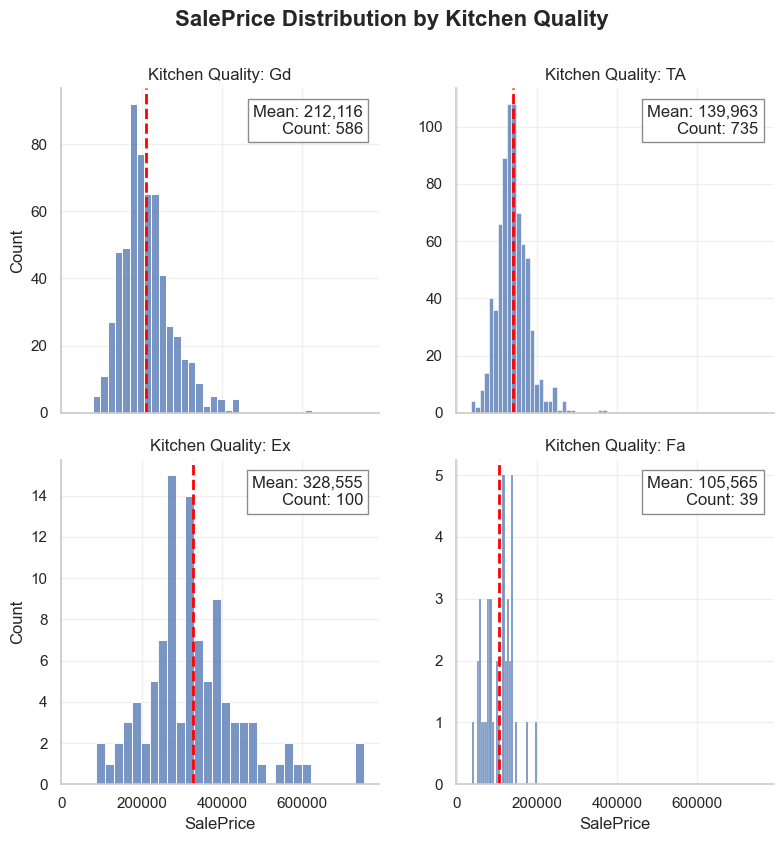

In [31]:
facet_grid = sns.FacetGrid(
    df,
    col="KitchenQual",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=False
)

facet_grid.map_dataframe(saleprice_hist_with_stats)
facet_grid.set_axis_labels("SalePrice", "Count")
facet_grid.set_titles("Kitchen Quality: {col_name}")
facet_grid.fig.suptitle("SalePrice Distribution by Kitchen Quality", y=1.05, fontsize=16, fontweight="bold")

facet_grid.savefig(FIGURES_DIR / "w3_facetgrid.png", dpi=150)
plt.show()


In [32]:
step6_summary = f'''
Step 6 — Seaborn Advanced

OverallQual_Bin Distribution:
{df["OverallQual_Bin"].value_counts()}

KitchenQual Distribution:
{df["KitchenQual"].value_counts()}
'''

with open(REPORTS_DIR / "step6_seaborn_advanced_summary.txt", "w", encoding="utf-8") as f:
    f.write(step6_summary)

df["OverallQual_Bin"].value_counts().to_csv(REPORTS_DIR / "step6_overallqual_bin_counts.csv")
df["KitchenQual"].value_counts().to_csv(REPORTS_DIR / "step6_kitchenqual_counts.csv")

print("Step 6 report saved.")


Step 6 report saved.


**Summary**

The pair plot displays relationships between major numerical features. The FacetGrid compares `SalePrice` distributions across kitchen quality levels, showing how quality affects pricing.


# Step 7

This step creates 8 engineered features.


In [33]:
print("="*60)
print("Step 7: Feature creation - 8 engineered features")
print("="*60)


Step 7: Feature creation - 8 engineered features


In [34]:
# TotalSF captures the complete property area by combining basement, first floor, and second floor area.
df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"].fillna(0) + df["2ndFlrSF"].fillna(0)

# TotalBaths creates a weighted bathroom count because full baths have more value than half baths.
df["TotalBaths"] = df["FullBath"].fillna(0) + 0.5*df["HalfBath"].fillna(0) + df["BsmtFullBath"].fillna(0) + 0.5*df["BsmtHalfBath"].fillna(0)

# HouseAge measures how old the house was at the time of sale.
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# RemodelAge measures how many years passed since the last remodel at the time of sale.
df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]

# HasRemodeled indicates whether the house has been remodeled after construction.
df["HasRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

# QualCond captures interaction between overall quality and overall condition.
df["QualCond"] = df["OverallQual"] * df["OverallCond"]

# PricePerSF measures price density and normalizes price by total house area.
df["PricePerSF"] = np.where(df["TotalSF"] > 0, df["SalePrice"] / df["TotalSF"], 0)

# IsNewHouse identifies houses built within 5 years before the sale.
df["IsNewHouse"] = (df["YearBuilt"] >= df["YrSold"] - 5).astype(int)

new_features = ["TotalSF", "TotalBaths", "HouseAge", "RemodelAge", "HasRemodeled", "QualCond", "PricePerSF", "IsNewHouse"]


In [35]:
print("="*60)
print("Engineered features description")
print("="*60)
display(df[new_features].describe())

print("="*60)
print("First 10 rows of engineered features")
print("="*60)
display(df[new_features].head(10))


Engineered features description


,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,2567.048630,2.210616,36.547945,22.950000,0.476712,33.864384,69.944000,0.212329
std,821.714421,0.785399,30.250152,20.640653,0.499629,9.219624,15.397065,0.409096
min,334.000000,1.000000,0.000000,-1.000000,0.000000,1.000000,13.614704,0.000000
25%,2009.500000,2.000000,8.000000,4.000000,0.000000,30.000000,60.461553,0.000000
50%,2474.000000,2.000000,35.000000,14.000000,0.000000,35.000000,69.679436,0.000000
75%,3004.000000,2.500000,54.000000,41.000000,1.000000,40.000000,78.949872,0.000000
max,11752.000000,6.000000,136.000000,60.000000,1.000000,90.000000,138.125440,1.000000


First 10 rows of engineered features


,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
0,2566,3.5,5,5,0,35,81.254871,1
1,2524,2.5,31,31,0,48,71.909667,0
2,2706,3.5,7,6,1,35,82.594235,0
3,2473,2.0,91,36,1,35,56.611403,0
4,3343,3.5,8,8,0,40,74.783129,0
5,2158,2.5,16,14,1,25,66.265060,0
6,3380,3.0,3,2,1,40,90.828402,1
7,3197,3.5,36,36,0,42,62.558649,0
8,2726,2.0,77,58,1,35,47.652238,0
9,2068,2.0,69,58,1,30,57.059961,0


In [36]:
df[new_features].describe().to_csv(REPORTS_DIR / "step7_engineered_features_describe.csv")
df[new_features].head(10).to_csv(REPORTS_DIR / "step7_engineered_features_preview.csv", index=False)

step7_summary = f'''
Step 7 — Feature Creation

New Features Created:
{new_features}
'''

with open(REPORTS_DIR / "step7_feature_creation_summary.txt", "w", encoding="utf-8") as f:
    f.write(step7_summary)

print("Step 7 reports saved.")


Step 7 reports saved.


**Summary**

Eight engineered features were created to improve prediction power. These features capture property size, bathroom count, age, remodeling status, quality-condition interaction, price density, and whether a house is new.


# Step 8
This step checks whether engineered features are useful.


In [37]:
print("="*60)
print("Step 8: Correlation analysis of engineered features")
print("="*60)


Step 8: Correlation analysis of engineered features


In [38]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_with_saleprice = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
abs_corr_with_saleprice = corr_with_saleprice.abs().sort_values(ascending=False)

top20_corr = abs_corr_with_saleprice.head(20)
bottom10_corr = abs_corr_with_saleprice.tail(10)
engineered_in_top20 = [feature for feature in new_features if feature in top20_corr.index.tolist()]

print("Top 20 correlations:")
print(top20_corr)

print("\nBottom 10 correlations:")
print(bottom10_corr)

print("\nEngineered features in top 20:")
print(engineered_in_top20)


Top 20 correlations:
SalePrice           1.000000
OverallQual         0.790982
TotalSF             0.782260
GrLivArea           0.708624
PricePerSF          0.640602
GarageCars          0.640409
TotalBaths          0.631731
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
QualCond            0.565294
FullBath            0.560664
TotRmsAbvGrd        0.533723
HouseAge            0.523350
YearBuilt           0.522897
YearBuilt_Decade    0.515824
RemodelAge          0.509079
YearRemodAdd        0.507101
GarageYrBlt         0.486362
MasVnrArea          0.477493
Name: SalePrice, dtype: float64

Bottom 10 correlations:
OverallCond     0.077856
MoSold          0.046432
3SsnPorch       0.044584
YrSold          0.028923
LowQualFinSF    0.025606
HasRemodeled    0.021933
Id              0.021917
MiscVal         0.021190
BsmtHalfBath    0.016844
BsmtFinSF2      0.011378
Name: SalePrice, dtype: float64

Engineered features in top 20:
['TotalSF', 'TotalBaths', 'H

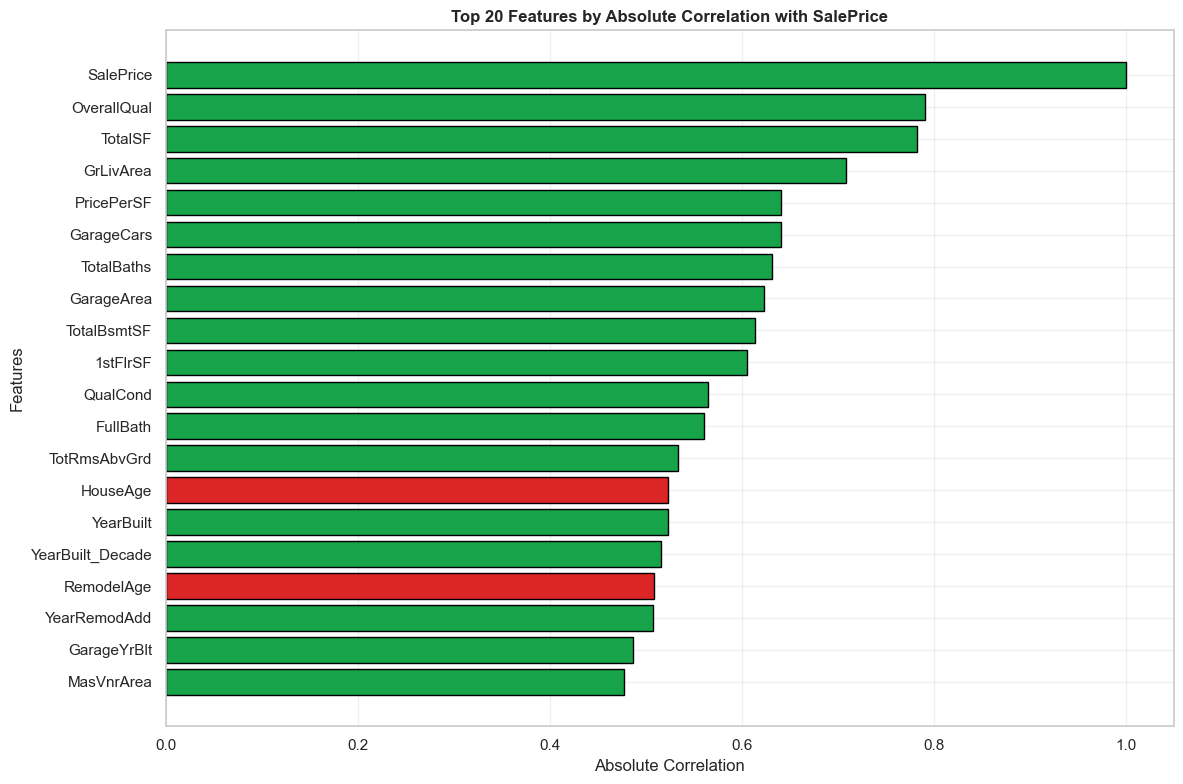

In [39]:
top20_direction = corr_with_saleprice.loc[top20_corr.index]
colors = ["#16A34A" if value > 0 else "#DC2626" for value in top20_direction.values]

plt.figure(figsize=(12, 8))
plt.barh(top20_corr.sort_values().index, top20_corr.sort_values().values, color=colors[::-1], edgecolor="black")
plt.title("Top 20 Features by Absolute Correlation with SalePrice", fontweight="bold")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step8_top20_feature_correlations.png", dpi=150)
plt.show()


In [40]:
top20_corr.to_csv(REPORTS_DIR / "step8_top20_correlations.csv")
bottom10_corr.to_csv(REPORTS_DIR / "step8_bottom10_correlations.csv")

step8_summary = f'''
Step 8 — Correlation Analysis of Engineered Features

Top 20 Correlations:
{top20_corr}

Bottom 10 Correlations:
{bottom10_corr}

Engineered Features in Top 20:
{engineered_in_top20}
'''

with open(REPORTS_DIR / "step8_correlation_analysis_summary.txt", "w", encoding="utf-8") as f:
    f.write(step8_summary)

print("Step 8 reports saved.")


Step 8 reports saved.


**Summary**

The engineered features were evaluated using correlation with `SalePrice`. If engineered features appear in the top 20, it means feature engineering added meaningful predictive value.


# Step 9
This step analyzes categorical columns and builds an encoding decision table.


In [41]:
print("="*60)
print("Step 9: Categorical variable analysis and encoding strategy")
print("="*60)


Step 9: Categorical variable analysis and encoding strategy


In [42]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("Total categorical columns:", len(categorical_cols))
print(categorical_cols)


Total categorical columns: 44
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'YearBuilt_Decade_Label']


In [43]:
encoding_rows = []

ordinal_quality_cols = ["ExterQual", "KitchenQual", "BsmtQual", "GarageQual", "FireplaceQu", "ExterCond", "BsmtCond", "GarageCond", "HeatingQC", "PoolQC"]

for col in categorical_cols:
    unique_count = df[col].nunique(dropna=True)
    missing_pct = df[col].isnull().mean() * 100
    dominant_pct = df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100 if unique_count > 0 else 0

    print("="*60)
    print(f"Column: {col}")
    print("="*60)
    print("Unique categories:", unique_count)
    print("Missing percentage:", round(missing_pct, 2))
    print("\nValue counts:")
    print(df[col].value_counts(dropna=False).head(15))
    print("\nMean SalePrice per category:")
    print(df.groupby(col)["SalePrice"].mean().sort_values(ascending=False).head(15))

    if missing_pct > 50 or dominant_pct > 95:
        strategy = "drop"
        reason = "High missing percentage or one dominant value"
    elif col in ordinal_quality_cols:
        strategy = "label_encode"
        reason = "Ordinal quality scale exists"
    elif unique_count <= 10:
        strategy = "onehot_encode"
        reason = "Nominal categorical column with 10 or fewer categories"
    else:
        strategy = "frequency_encode"
        reason = "Nominal categorical column with more than 10 categories"

    encoding_rows.append({
        "Column": col,
        "Unique_Categories": unique_count,
        "Missing_Percentage": round(missing_pct, 2),
        "Dominant_Percentage": round(dominant_pct, 2),
        "Encoding_Strategy": strategy,
        "Reason": reason
    })

encoding_strategy_df = pd.DataFrame(encoding_rows)
display(encoding_strategy_df)


Column: MSZoning
Unique categories: 5
Missing percentage: 0.0

Value counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Mean SalePrice per category:
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64
Column: Street
Unique categories: 2
Missing percentage: 0.0

Value counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Mean SalePrice per category:
Street
Pave    181130.538514
Grvl    130190.500000
Name: SalePrice, dtype: float64
Column: Alley
Unique categories: 2
Missing percentage: 93.77

Value counts:
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Mean SalePrice per category:
Alley
Pave    168000.585366
Grvl    122219.080000
Name: SalePrice, dtype: float64
Column: LotShape
Unique categories: 4
Missing percentage: 0.0

Value counts:
LotShape
Reg    925
IR1    48

,Column,Unique_Categories,Missing_Percentage,Dominant_Percentage,Encoding_Strategy,Reason
0,MSZoning,5,0.00,78.84,onehot_encode,Nominal categorical column with 10 or fewer ca...
1,Street,2,0.00,99.59,drop,High missing percentage or one dominant value
2,Alley,2,93.77,54.95,drop,High missing percentage or one dominant value
3,LotShape,4,0.00,63.36,onehot_encode,Nominal categorical column with 10 or fewer ca...
4,LandContour,4,0.00,89.79,onehot_encode,Nominal categorical column with 10 or fewer ca...
5,Utilities,2,0.00,99.93,drop,High missing percentage or one dominant value
6,LotConfig,5,0.00,72.05,onehot_encode,Nominal categorical column with 10 or fewer ca...
7,LandSlope,3,0.00,94.66,onehot_encode,Nominal categorical column with 10 or fewer ca...
8,Neighborhood,25,0.00,15.41,frequency_encode,Nominal categorical column with more than 10 c...
9,Condition1,9,0.00,86.30,onehot_encode,Nominal categorical column with 10 or fewer ca...


In [44]:
encoding_strategy_df.to_csv(REPORTS_DIR / "step9_encoding_strategy.csv", index=False)

step9_summary = f'''
Step 9 — Categorical Variable Analysis and Encoding Strategy

Encoding Strategy Table:
{encoding_strategy_df}
'''

with open(REPORTS_DIR / "step9_encoding_strategy_summary.txt", "w", encoding="utf-8") as f:
    f.write(step9_summary)

print("Step 9 reports saved.")


Step 9 reports saved.


**Summary**

Categorical features were analyzed using unique count, missing percentage, dominant value percentage, and mean `SalePrice` per category. Encoding strategies were selected based on whether columns were ordinal, nominal, high-cardinality, or weak due to missing/dominant values.


# Step 10

This step applies label encoding, one-hot encoding, frequency encoding, and dropping.


In [45]:
print("="*60)
print("Step 10: Apply all encoding strategies")
print("="*60)


Step 10: Apply all encoding strategies


In [46]:
df_encoded = df.copy()
shape_before_encoding = df_encoded.shape

quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}

label_encode_cols = encoding_strategy_df[encoding_strategy_df["Encoding_Strategy"] == "label_encode"]["Column"].tolist()
onehot_encode_cols = encoding_strategy_df[encoding_strategy_df["Encoding_Strategy"] == "onehot_encode"]["Column"].tolist()
frequency_encode_cols = encoding_strategy_df[encoding_strategy_df["Encoding_Strategy"] == "frequency_encode"]["Column"].tolist()
drop_cols = encoding_strategy_df[encoding_strategy_df["Encoding_Strategy"] == "drop"]["Column"].tolist()

print("Label encode columns:", label_encode_cols)
print("One-hot encode columns:", onehot_encode_cols)
print("Frequency encode columns:", frequency_encode_cols)
print("Drop columns:", drop_cols)


Label encode columns: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu']
One-hot encode columns: ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']
Frequency encode columns: ['Neighborhood', 'Exterior1st', 'Exterior2nd', 'YearBuilt_Decade_Label']
Drop columns: ['Street', 'Alley', 'Utilities', 'Condition2', 'RoofMatl', 'MasVnrType', 'Heating', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


In [47]:
for col in label_encode_cols:
    df_encoded[col] = df_encoded[col].fillna("NA").map(quality_map)

for col in frequency_encode_cols:
    freq = df_encoded[col].value_counts(normalize=True)
    df_encoded[col + "_freq"] = df_encoded[col].map(freq)
    df_encoded.drop(columns=[col], inplace=True)

df_encoded = pd.get_dummies(df_encoded, columns=onehot_encode_cols, drop_first=True)

existing_drop_cols = [col for col in drop_cols if col in df_encoded.columns]
df_encoded.drop(columns=existing_drop_cols, inplace=True)

remaining_object_cols = df_encoded.select_dtypes(include=["object", "string"]).columns.tolist()
shape_after_encoding = df_encoded.shape

print("Shape before encoding:", shape_before_encoding)
print("Shape after encoding:", shape_after_encoding)
print("Remaining object columns:", remaining_object_cols)


Shape before encoding: (1460, 92)
Shape after encoding: (1460, 150)
Remaining object columns: []


In [48]:
pd.DataFrame({
    "Shape": ["Before Encoding", "After Encoding"],
    "Rows": [shape_before_encoding[0], shape_after_encoding[0]],
    "Columns": [shape_before_encoding[1], shape_after_encoding[1]]
}).to_csv(REPORTS_DIR / "step10_encoding_shape_comparison.csv", index=False)

pd.DataFrame({"remaining_object_columns": remaining_object_cols}).to_csv(REPORTS_DIR / "step10_remaining_object_columns.csv", index=False)
df_encoded.head(20).to_csv(REPORTS_DIR / "step10_encoded_preview.csv", index=False)

step10_summary = f'''
Step 10 — Apply All Encoding Strategies

Shape Before Encoding: {shape_before_encoding}
Shape After Encoding: {shape_after_encoding}
Remaining Object Columns: {remaining_object_cols}
'''

with open(REPORTS_DIR / "step10_encoding_summary.txt", "w", encoding="utf-8") as f:
    f.write(step10_summary)

print("Step 10 reports saved.")


Step 10 reports saved.


**Summary**

Encoding strategies were applied according to the decision table. Ordinal quality columns were label encoded, low-cardinality nominal features were one-hot encoded, high-cardinality features were frequency encoded, and weak columns were dropped.


# Step 11

This step compares StandardScaler, MinMaxScaler, and RobustScaler.


In [49]:
print("="*60)
print("Step 11: Feature scaling - compare three methods")
print("="*60)


Step 11: Feature scaling - compare three methods


In [50]:
model_df = df_encoded.select_dtypes(include=["number"]).copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).fillna(0)

X = model_df.drop("SalePrice", axis=1)
y = model_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

selected_features_for_scaling = ["GrLivArea", "TotalSF", "OverallQual"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1168, 57)
X_test shape: (292, 57)


In [51]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

scaling_summary_rows = {}

for scaler_name, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

    summary_rows = []
    for feature in selected_features_for_scaling:
        summary_rows.append({
            "Feature": feature,
            "Before_Mean": X_train[feature].mean(),
            "Before_Std": X_train[feature].std(),
            "After_Mean": X_train_scaled_df[feature].mean(),
            "After_Std": X_train_scaled_df[feature].std()
        })

    scaling_summary_rows[scaler_name] = pd.DataFrame(summary_rows)

    print("="*60)
    print(scaler_name)
    print("="*60)
    display(scaling_summary_rows[scaler_name])


StandardScaler


,Feature,Before_Mean,Before_Std,After_Mean,After_Std
0,GrLivArea,1527.401541,524.432686,-1.307934e-16,1.000428
1,TotalSF,2583.476884,821.305316,1.429602e-16,1.000428
2,OverallQual,6.121575,1.367619,-5.170902e-17,1.000428


MinMaxScaler


,Feature,Before_Mean,Before_Std,After_Mean,After_Std
0,GrLivArea,1527.401541,524.432686,0.224831,0.098800
1,TotalSF,2583.476884,821.305316,0.197011,0.071931
2,OverallQual,6.121575,1.367619,0.569064,0.151958


RobustScaler


,Feature,Before_Mean,Before_Std,After_Mean,After_Std
0,GrLivArea,1527.401541,524.432686,0.084180,0.811501
1,TotalSF,2583.476884,821.305316,0.091210,0.837212
2,OverallQual,6.121575,1.367619,0.060788,0.683810


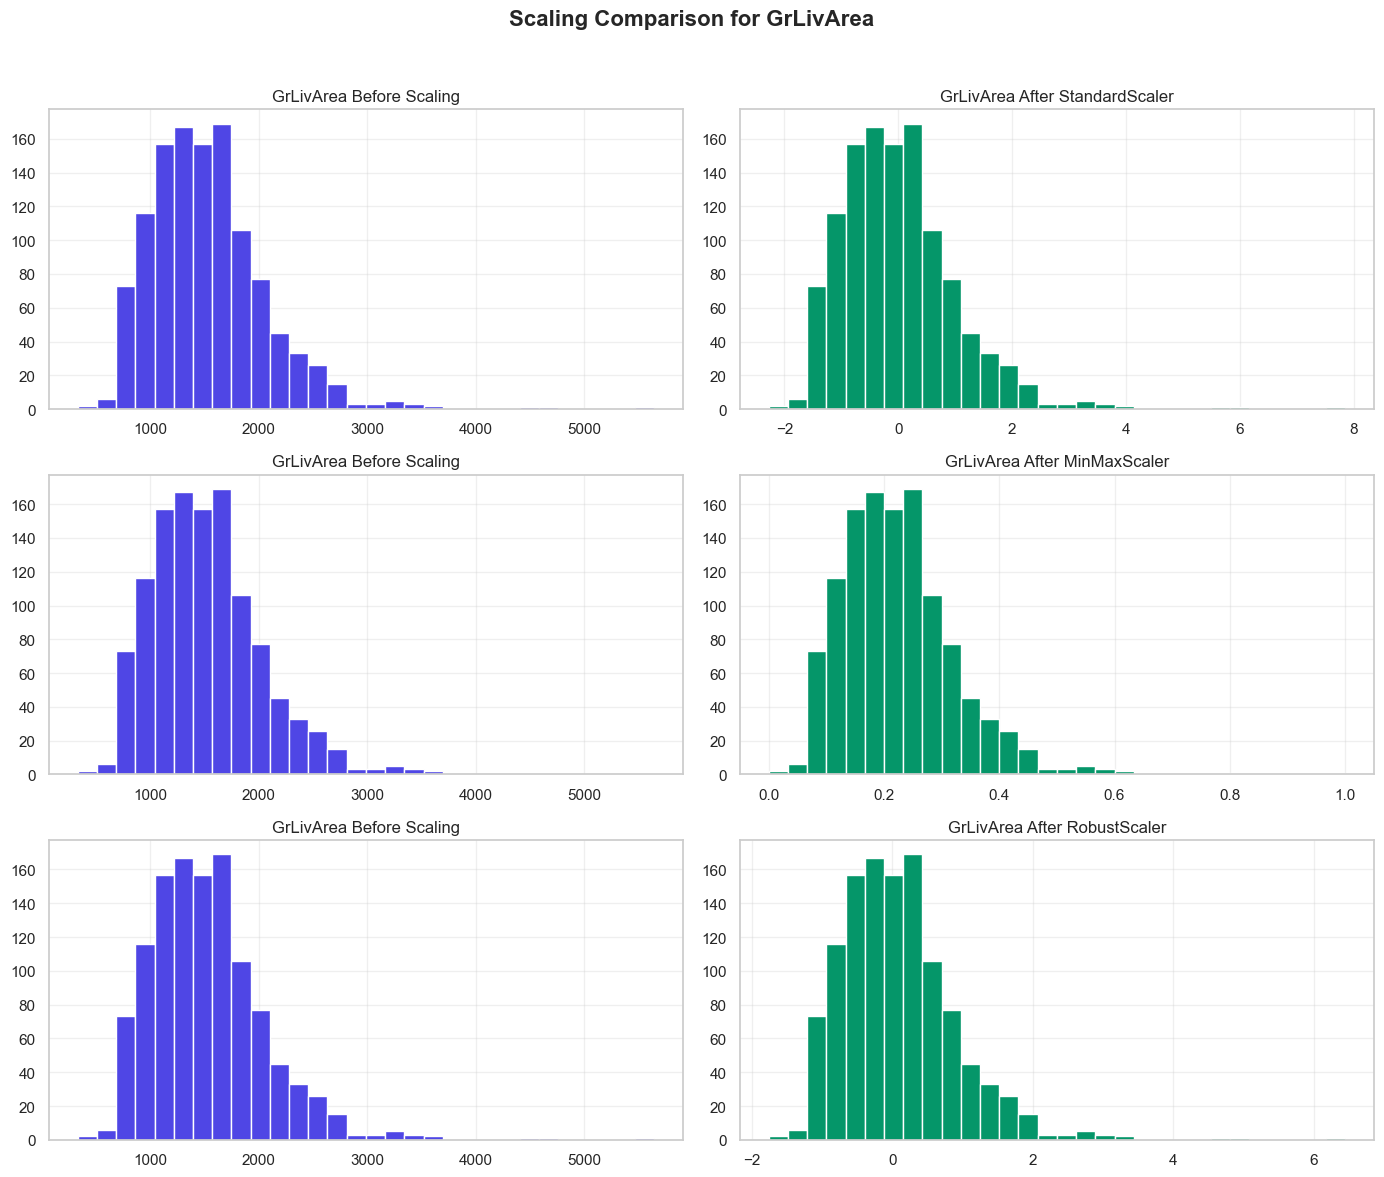

In [52]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, (scaler_name, scaler) in enumerate(scalers.items()):
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

    axes[i, 0].hist(X_train["GrLivArea"], bins=30, color="#4F46E5", edgecolor="white")
    axes[i, 0].set_title("GrLivArea Before Scaling")

    axes[i, 1].hist(X_train_scaled_df["GrLivArea"], bins=30, color="#059669", edgecolor="white")
    axes[i, 1].set_title(f"GrLivArea After {scaler_name}")

plt.suptitle("Scaling Comparison for GrLivArea", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / "step11_scaling_comparison.png", dpi=150)
plt.show()


In [55]:
pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
with pd.ExcelWriter(REPORTS_DIR / "step11_scaling_summary.xlsx") as writer:
    for scaler_name, summary_df in scaling_summary_rows.items():
        summary_df.to_excel(writer, sheet_name=scaler_name, index=False)

step11_summary = '''
Step 11 — Feature Scaling Comparison

StandardScaler, MinMaxScaler, and RobustScaler were applied.
For Week 4 Linear Regression, StandardScaler is usually preferred because it centers features around mean 0 and standard deviation 1.
'''

with open(REPORTS_DIR / "step11_scaling_summary.txt", "w", encoding="utf-8") as f:
    f.write(step11_summary)

print("Step 11 reports saved.")


Step 11 reports saved.


****Summary**

StandardScaler, MinMaxScaler, and RobustScaler were compared. For linear regression, StandardScaler is preferred because it standardizes features around mean 0 and standard deviation 1.


# Step 12

This step detects skewness and classifies severity.


In [ ]:
print("="*60)
print("Step 12: Skewness detection and visualization")
print("="*60)


In [ ]:
numeric_df_before_scaling = df_encoded.select_dtypes(include=["number"]).copy()
skew_values = numeric_df_before_scaling.skew().sort_values(key=lambda x: x.abs(), ascending=False)

def classify_skewness(value):
    abs_value = abs(value)
    if abs_value < 0.5:
        return "Normal"
    elif abs_value < 1:
        return "Moderate"
    elif abs_value < 2:
        return "High"
    else:
        return "Very High"

skewness_report = pd.DataFrame({
    "Column": skew_values.index,
    "Skewness": skew_values.values
})

skewness_report["Severity"] = skewness_report["Skewness"].apply(classify_skewness)

display(skewness_report.head(20))

highly_skewed_count = (skewness_report["Skewness"].abs() > 1).sum()
total_numeric_features = len(skewness_report)
highly_skewed_percentage = (highly_skewed_count / total_numeric_features) * 100

print("Features with |skew| > 1:", highly_skewed_count)
print("Percentage highly skewed:", round(highly_skewed_percentage, 2), "%")


In [ ]:
top15_skewed = skewness_report.head(15)

severity_color_map = {
    "Normal": "#22C55E",
    "Moderate": "#EAB308",
    "High": "#F97316",
    "Very High": "#DC2626"
}

colors = top15_skewed["Severity"].map(severity_color_map)

plt.figure(figsize=(12, 8))
plt.barh(top15_skewed["Column"][::-1], top15_skewed["Skewness"][::-1], color=colors[::-1], edgecolor="black")
plt.title("Top 15 Most Skewed Numerical Features", fontweight="bold")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "step12_skewness_bar_chart.png", dpi=150)
plt.show()


In [ ]:
skewness_report.to_csv(REPORTS_DIR / "step12_skewness_report.csv", index=False)

step12_summary = f'''
Step 12 — Skewness Detection

Features with |skew| > 1: {highly_skewed_count}
Percentage highly skewed: {highly_skewed_percentage:.2f}%
'''

with open(REPORTS_DIR / "step12_skewness_summary.txt", "w", encoding="utf-8") as f:
    f.write(step12_summary)

print("Step 12 reports saved.")


**Summary**

Skewness was calculated for all numerical features. Highly skewed features can negatively affect linear models, so they are important to identify before transformation.


# Step 13
This step applies log transformations and compares SalePrice transformations.


In [ ]:
print("="*60)
print("Step 13: Apply skewness transformations")
print("="*60)


In [ ]:
df_transformed = df_encoded.copy()
df_transformed = df_transformed.replace([np.inf, -np.inf], np.nan).fillna(0)

numeric_cols_trans = df_transformed.select_dtypes(include=["number"]).columns.tolist()
skew_before = df_transformed[numeric_cols_trans].skew()

skewed_features = skew_before[(skew_before.abs() > 0.75) & (skew_before.index != "SalePrice")].index.tolist()

for col in skewed_features:
    if df_transformed[col].min() >= 0:
        df_transformed[col] = np.log1p(df_transformed[col])

print("Number of transformed skewed features:", len(skewed_features))
print(skewed_features[:20])


In [ ]:
saleprice_original = df["SalePrice"]
saleprice_log = np.log1p(saleprice_original)
saleprice_sqrt = np.sqrt(saleprice_original)
positive_saleprice = saleprice_original[saleprice_original > 0]
saleprice_boxcox, boxcox_lambda = stats.boxcox(positive_saleprice)

print("Original SalePrice skew:", saleprice_original.skew())
print("Log1p SalePrice skew:", pd.Series(saleprice_log).skew())
print("Sqrt SalePrice skew:", pd.Series(saleprice_sqrt).skew())
print("Box-Cox SalePrice skew:", pd.Series(saleprice_boxcox).skew())
print("Box-Cox lambda:", boxcox_lambda)

df_transformed["SalePrice_transformed"] = np.log1p(df_transformed["SalePrice"])


In [ ]:
features_to_compare = ["SalePrice"] + [col for col in skewed_features[:3] if col in df_encoded.columns]

fig, axes = plt.subplots(len(features_to_compare), 2, figsize=(14, 4 * len(features_to_compare)))
if len(features_to_compare) == 1:
    axes = np.array([axes])

for i, col in enumerate(features_to_compare):
    original = df_encoded[col].replace([np.inf, -np.inf], np.nan).dropna()
    transformed = np.log1p(original) if original.min() >= 0 else original

    axes[i, 0].hist(original, bins=30, color="#4F46E5", edgecolor="white")
    axes[i, 0].set_title(f"Original {col} (skew={original.skew():.2f})")

    axes[i, 1].hist(transformed, bins=30, color="#059669", edgecolor="white")
    axes[i, 1].set_title(f"Transformed {col} (skew={pd.Series(transformed).skew():.2f})")

plt.suptitle("Skewness Treatment: Before vs After", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / "step13_skewness_before_after.png", dpi=150)
plt.show()


In [ ]:
skew_after = df_transformed.select_dtypes(include=["number"]).skew()

skew_compare = pd.DataFrame({
    "Original_Skewness": skew_before,
    "Transformed_Skewness": skew_after
}).dropna()

skew_compare.to_csv(REPORTS_DIR / "step13_skewness_before_after.csv")

step13_summary = f'''
Step 13 — Skewness Transformation

Number of features transformed:
{len(skewed_features)}

SalePrice Transformation Comparison:
Original Skew: {saleprice_original.skew():.4f}
Log1p Skew: {pd.Series(saleprice_log).skew():.4f}
Sqrt Skew: {pd.Series(saleprice_sqrt).skew():.4f}
Box-Cox Skew: {pd.Series(saleprice_boxcox).skew():.4f}
Box-Cox Lambda: {boxcox_lambda:.4f}

Selected SalePrice Transformation:
log1p transformation saved as SalePrice_transformed.
'''

with open(REPORTS_DIR / "step13_skewness_transformation_summary.txt", "w", encoding="utf-8") as f:
    f.write(step13_summary)

print("Step 13 reports saved.")


**Summary**

Highly skewed features were transformed using `np.log1p()` where possible. For `SalePrice`, log, square-root, and Box-Cox transformations were compared. Log transformation is commonly effective for right-skewed price data.


# Step 14
This step selects top features using correlation, variance threshold, and multicollinearity removal.


In [ ]:
print("="*60)
print("Step 14: Feature selection")
print("="*60)


In [ ]:
selection_df = df_transformed.select_dtypes(include=["number"]).copy()
selection_df = selection_df.replace([np.inf, -np.inf], np.nan).fillna(0)

target_col = "SalePrice"

feature_corr = selection_df.corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
top30_features = feature_corr.head(30).index.tolist()

print("Top 30 correlation-based features:")
print(top30_features)


In [ ]:
X_selection = selection_df[top30_features]

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_selection)

variance_selected_features = X_selection.columns[vt.get_support()].tolist()

print("Features after variance threshold:", len(variance_selected_features))
print(variance_selected_features)


In [ ]:
corr_matrix = selection_df[variance_selected_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

features_to_drop = []

for col in upper.columns:
    high_corr_features = upper.index[upper[col] > 0.95].tolist()
    for row in high_corr_features:
        corr_col = feature_corr.get(col, 0)
        corr_row = feature_corr.get(row, 0)
        if corr_col < corr_row:
            features_to_drop.append(col)
        else:
            features_to_drop.append(row)

features_to_drop = list(set(features_to_drop))
final_selected_features = [feature for feature in variance_selected_features if feature not in features_to_drop]

print("Features dropped due to multicollinearity:")
print(features_to_drop)

print("\nFinal selected features:")
print(final_selected_features)

print("\nNumber of final features:", len(final_selected_features))


In [ ]:
final_feature_table = pd.DataFrame({
    "Feature": final_selected_features,
    "Correlation_With_SalePrice": [feature_corr.get(feature, np.nan) for feature in final_selected_features],
    "Data_Type": [selection_df[feature].dtype for feature in final_selected_features]
}).sort_values(by="Correlation_With_SalePrice", ascending=False)

original_feature_count = df.shape[1]
final_feature_count = len(final_selected_features)
eliminated_percentage = ((original_feature_count - final_feature_count) / original_feature_count) * 100

display(final_feature_table)

print("Original feature count:", original_feature_count)
print("Final feature count:", final_feature_count)
print("Percentage eliminated:", round(eliminated_percentage, 2), "%")


In [ ]:
final_feature_table.to_csv(REPORTS_DIR / "step14_selected_features.csv", index=False)

step14_summary = f'''
Step 14 — Feature Selection

Original Feature Count:
{original_feature_count}

Final Feature Count:
{final_feature_count}

Percentage Eliminated:
{eliminated_percentage:.2f}%

Features Dropped due to Multicollinearity:
{features_to_drop}

Final Selected Features:
{final_selected_features}
'''

with open(REPORTS_DIR / "step14_feature_selection_summary.txt", "w", encoding="utf-8") as f:
    f.write(step14_summary)

print("Step 14 reports saved.")


**Summary**

Feature selection removed weak and redundant variables using correlation, variance threshold, and multicollinearity checks. The final selected features are more useful and cleaner for future model training.


# Step 15

This step creates three production-quality functions with docstrings and type hints.


In [ ]:
print("="*60)
print("Step 15: Reusable feature engineering functions")
print("="*60)


In [ ]:
def visualize_distributions(df: pd.DataFrame, cols: List[str], n_cols: int = 3) -> None:
    '''
    Create a multi-panel histogram grid for numerical columns.

    Parameters:
        df: Input dataframe.
        cols: List of numerical columns.
        n_cols: Number of subplot columns.
    '''
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        data = df[col].dropna()
        skewness = data.skew()
        axes[i].hist(data, bins=30, color="#4F46E5", edgecolor="white")
        axes[i].set_title(f"{col} (skew={skewness:.2f})")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
def encode_quality_column(series: pd.Series, quality_map: Optional[Dict[str, int]] = None) -> Tuple[pd.Series, Dict[str, int]]:
    '''
    Encode a quality categorical column using a quality map.

    Parameters:
        series: Quality categorical series.
        quality_map: Optional custom mapping.

    Returns:
        Encoded series and mapping used.
    '''
    if quality_map is None:
        quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}

    encoded_series = series.fillna("NA").map(quality_map)
    return encoded_series, quality_map


In [ ]:
def full_scaling_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    method: str = "standard"
) -> Tuple[np.ndarray, np.ndarray, Any]:
    '''
    Fit scaler on training data and transform train and test.

    Parameters:
        X_train: Training features.
        X_test: Testing features.
        method: standard, minmax, or robust.

    Returns:
        Scaled train array, scaled test array, fitted scaler.
    '''
    if method == "standard":
        scaler = StandardScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    elif method == "robust":
        scaler = RobustScaler()
    else:
        raise ValueError("method must be 'standard', 'minmax', or 'robust'")

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler


In [ ]:
print("Testing visualize_distributions function:")
visualize_distributions(df, ["SalePrice", "GrLivArea", "TotalBsmtSF"], n_cols=3)

print("Testing encode_quality_column function:")
encoded_kitchen_qual, used_map = encode_quality_column(df["KitchenQual"])
print(encoded_kitchen_qual.head())
print("Mapping used:", used_map)

print("Testing full_scaling_pipeline function:")
X_train_scaled, X_test_scaled, fitted_scaler = full_scaling_pipeline(
    X_train[selected_features_for_scaling],
    X_test[selected_features_for_scaling],
    method="standard"
)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)
print("Scaler used:", fitted_scaler)


In [54]:
step15_summary = '''
Step 15 — Reusable Feature Engineering Functions

Functions Created:
1. visualize_distributions(df, cols, n_cols=3)
2. encode_quality_column(series, quality_map=None)
3. full_scaling_pipeline(X_train, X_test, method='standard')
'''

with open(REPORTS_DIR / "step15_functions_summary.txt", "w", encoding="utf-8") as f:
    f.write(step15_summary)

print("Step 15 report saved.")


Step 15 report saved.


**Summary**

Three reusable functions were created for visualization, quality encoding, and scaling. These functions make the workflow more professional and reusable.


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in ["notebook", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Figures folder:", FIGURES_DIR)

Figures folder: d:\AIML-Internship-Week3-IjazAhmad\outputs\figures


# Step 16
This step creates the final Week 3 dashboard and saves it as `week3_dashboard.png`.


In [ ]:
print("="*60)
print("Step 16: Final 6-chart professional dashboard")
print("="*60)


Step 16: Final 6-chart professional dashboard


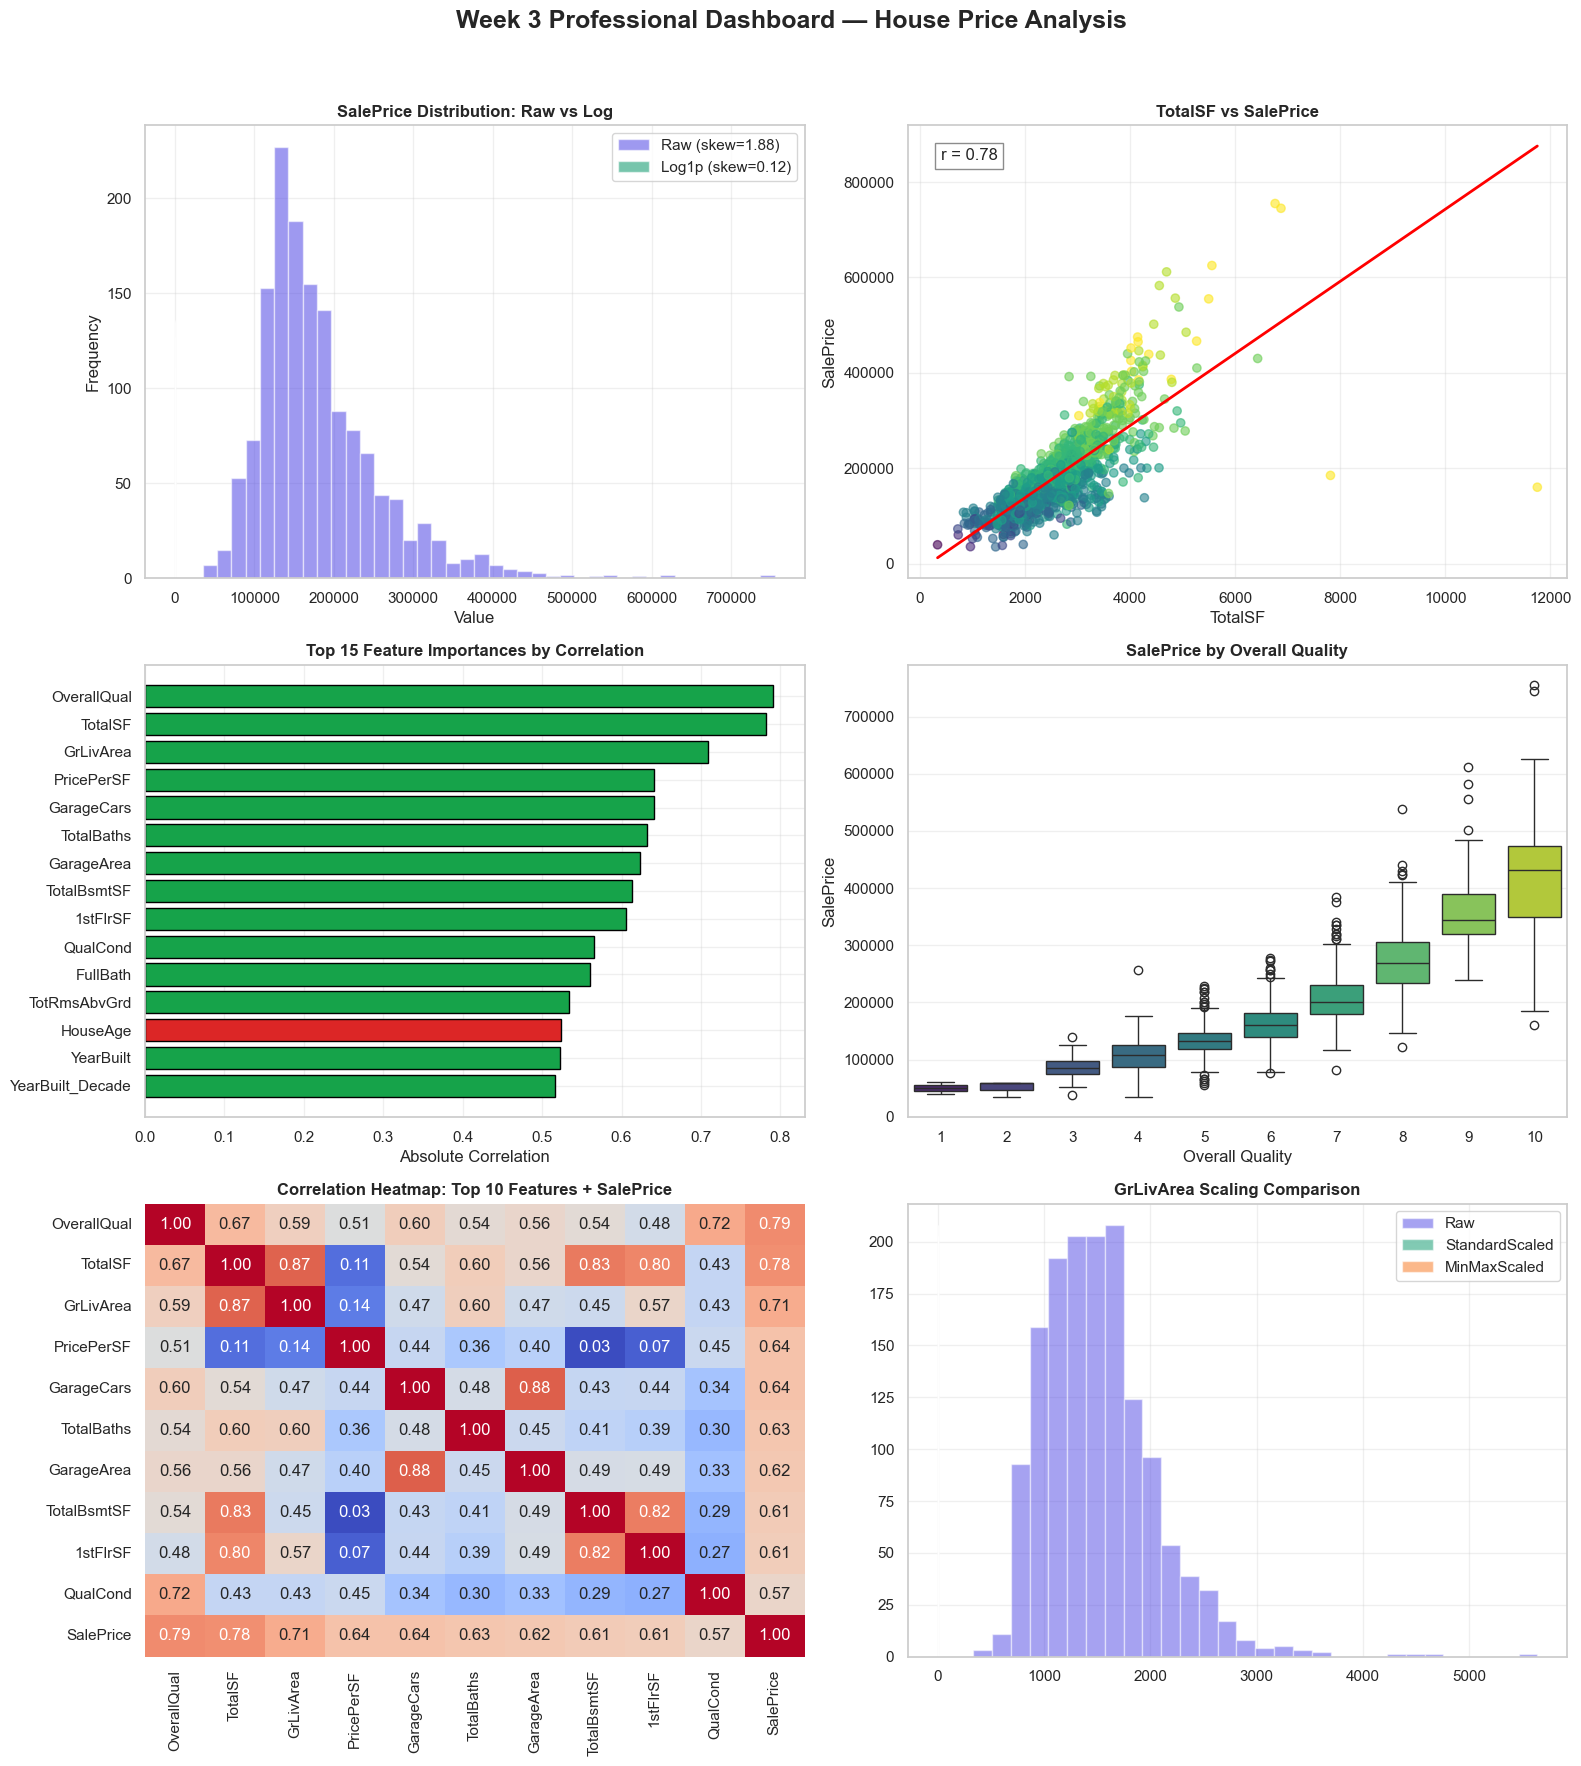

Dashboard saved successfully:
d:\AIML-Internship-Week3-IjazAhmad\outputs\figures\week3_dashboard.png


In [58]:
print("="*60)
print("Step 16: Final 6-chart professional dashboard")
print("="*60)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.close("all")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() in ["notebook", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Make sure required engineered features exist
if "TotalSF" not in df.columns:
    df["TotalSF"] = (
        df["TotalBsmtSF"].fillna(0)
        + df["1stFlrSF"].fillna(0)
        + df["2ndFlrSF"].fillna(0)
    )

if "TotalBaths" not in df.columns:
    df["TotalBaths"] = (
        df["FullBath"].fillna(0)
        + 0.5 * df["HalfBath"].fillna(0)
        + df["BsmtFullBath"].fillna(0)
        + 0.5 * df["BsmtHalfBath"].fillna(0)
    )

# Numeric data for correlation
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Top 15 correlated features
dashboard_corr = (
    numeric_df.corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .head(15)
)

dashboard_colors = [
    "#16A34A" if numeric_df[feature].corr(numeric_df["SalePrice"]) > 0 else "#DC2626"
    for feature in dashboard_corr.index
]

# Create dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Chart 1: SalePrice raw vs log
axes[0].hist(
    df["SalePrice"],
    bins=40,
    alpha=0.55,
    label=f"Raw (skew={df['SalePrice'].skew():.2f})",
    color="#4F46E5",
    edgecolor="white"
)

axes[0].hist(
    np.log1p(df["SalePrice"]),
    bins=40,
    alpha=0.55,
    label=f"Log1p (skew={np.log1p(df['SalePrice']).skew():.2f})",
    color="#059669",
    edgecolor="white"
)

axes[0].set_title("SalePrice Distribution: Raw vs Log", fontweight="bold")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Chart 2: TotalSF vs SalePrice
axes[1].scatter(
    df["TotalSF"],
    df["SalePrice"],
    c=df["OverallQual"],
    cmap="viridis",
    alpha=0.6
)

z = np.polyfit(df["TotalSF"], df["SalePrice"], 1)
p = np.poly1d(z)

x_line = np.linspace(df["TotalSF"].min(), df["TotalSF"].max(), 100)

axes[1].plot(
    x_line,
    p(x_line),
    color="red",
    linewidth=2
)

r_value = df["TotalSF"].corr(df["SalePrice"])

axes[1].text(
    0.05,
    0.95,
    f"r = {r_value:.2f}",
    transform=axes[1].transAxes,
    va="top",
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9)
)

axes[1].set_title("TotalSF vs SalePrice", fontweight="bold")
axes[1].set_xlabel("TotalSF")
axes[1].set_ylabel("SalePrice")

# Chart 3: Top 15 feature importances
axes[2].barh(
    dashboard_corr.index[::-1],
    dashboard_corr.abs().values[::-1],
    color=dashboard_colors[::-1],
    edgecolor="black"
)

axes[2].set_title("Top 15 Feature Importances by Correlation", fontweight="bold")
axes[2].set_xlabel("Absolute Correlation")

# Chart 4: SalePrice by OverallQual
sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice",
    ax=axes[3],
    palette="viridis"
)

axes[3].set_title("SalePrice by Overall Quality", fontweight="bold")
axes[3].set_xlabel("Overall Quality")
axes[3].set_ylabel("SalePrice")

# Chart 5: Heatmap top 10 features + SalePrice
top10_dashboard_features = dashboard_corr.head(10).index.tolist() + ["SalePrice"]
corr_top10_dashboard = numeric_df[top10_dashboard_features].corr()

sns.heatmap(
    corr_top10_dashboard,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[4],
    cbar=False
)

axes[4].set_title("Correlation Heatmap: Top 10 Features + SalePrice", fontweight="bold")

# Chart 6: Scaling comparison
raw_grliv = df["GrLivArea"].fillna(0)

standard_grliv = (raw_grliv - raw_grliv.mean()) / raw_grliv.std()
minmax_grliv = (raw_grliv - raw_grliv.min()) / (raw_grliv.max() - raw_grliv.min())

axes[5].hist(
    raw_grliv,
    bins=30,
    alpha=0.5,
    label="Raw",
    color="#4F46E5"
)

axes[5].hist(
    standard_grliv,
    bins=30,
    alpha=0.5,
    label="StandardScaled",
    color="#059669"
)

axes[5].hist(
    minmax_grliv,
    bins=30,
    alpha=0.5,
    label="MinMaxScaled",
    color="#F97316"
)

axes[5].set_title("GrLivArea Scaling Comparison", fontweight="bold")
axes[5].legend()

plt.suptitle(
    "Week 3 Professional Dashboard — House Price Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(FIGURES_DIR / "week3_dashboard.png", dpi=150)
plt.show()

print("Dashboard saved successfully:")
print(FIGURES_DIR / "week3_dashboard.png")

In [ ]:
step16_summary = '''
Step 16 — Final Dashboard

The final dashboard contains:
1. SalePrice raw vs log distribution
2. TotalSF vs SalePrice scatter
3. Top 15 feature importances
4. SalePrice by OverallQual
5. Correlation heatmap
6. Scaling comparison
'''

with open(REPORTS_DIR / "step16_dashboard_summary.txt", "w", encoding="utf-8") as f:
    f.write(step16_summary)

print("Step 16 report saved.")


**Summary**

The final dashboard combines distribution analysis, relationship analysis, feature importance, categorical comparison, correlation analysis, and scaling comparison in one figure.


# Step 17

This step creates a 4-panel feature engineering pipeline infographic.


In [ ]:
print("="*60)
print("Step 17: Feature engineering summary infographic")
print("="*60)


In [ ]:
feature_corr_table = pd.DataFrame({
    "Feature": new_features,
    "Formula": [
        "TotalBsmtSF + 1stFlrSF + 2ndFlrSF",
        "FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath",
        "YrSold - YearBuilt",
        "YrSold - YearRemodAdd",
        "YearBuilt != YearRemodAdd",
        "OverallQual * OverallCond",
        "SalePrice / TotalSF",
        "YearBuilt >= YrSold - 5"
    ],
    "Correlation": [selection_df[feature].corr(selection_df["SalePrice"]) if feature in selection_df.columns else np.nan for feature in new_features]
})

encoding_counts = encoding_strategy_df["Encoding_Strategy"].value_counts()

skew_treated_features = [col for col in skewed_features if col in skew_compare.index]
skew_treatment_df = pd.DataFrame({
    "Feature": skew_treated_features,
    "Original_Skewness": [skew_compare.loc[col, "Original_Skewness"] for col in skew_treated_features],
    "Transformed_Skewness": [skew_compare.loc[col, "Transformed_Skewness"] for col in skew_treated_features]
})

top15_selected = final_feature_table.head(15)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].axis("off")
table1 = axes[0].table(cellText=feature_corr_table.round(3).values,
                       colLabels=feature_corr_table.columns, loc="center", cellLoc="center")
table1.auto_set_font_size(False)
table1.set_fontsize(7)
table1.scale(1, 1.4)
axes[0].set_title("Features Created", fontweight="bold")

axes[1].bar(encoding_counts.index, encoding_counts.values, color="#4F46E5", edgecolor="black")
axes[1].set_title("Encoding Decisions", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

axes[2].scatter(skew_treatment_df["Original_Skewness"], skew_treatment_df["Transformed_Skewness"], color="#059669", alpha=0.7)
axes[2].axline((0, 0), slope=1, color="red", linestyle="--")
axes[2].set_title("Skewness Treatment: Before vs After", fontweight="bold")
axes[2].set_xlabel("Original Skewness")
axes[2].set_ylabel("Transformed Skewness")

axes[3].axis("off")
table2 = axes[3].table(cellText=top15_selected.round(3).values,
                       colLabels=top15_selected.columns, loc="center", cellLoc="center")
table2.auto_set_font_size(False)
table2.set_fontsize(7)
table2.scale(1, 1.4)
axes[3].set_title("Final Feature Set — Top 15", fontweight="bold")

plt.suptitle("Week 3 Feature Engineering Pipeline Summary", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURES_DIR / "week3_fe_pipeline.png", dpi=150)
plt.show()


In [ ]:
feature_corr_table.to_csv(REPORTS_DIR / "step17_engineered_features_table.csv", index=False)
encoding_counts.to_csv(REPORTS_DIR / "step17_encoding_counts.csv")
skew_treatment_df.to_csv(REPORTS_DIR / "step17_skewness_treatment.csv", index=False)
top15_selected.to_csv(REPORTS_DIR / "step17_top15_selected_features.csv", index=False)

step17_summary = '''
Step 17 — Feature Engineering Infographic

The infographic summarizes:
1. Engineered features
2. Encoding decisions
3. Skewness treatment
4. Final selected feature set
'''

with open(REPORTS_DIR / "step17_infographic_summary.txt", "w", encoding="utf-8") as f:
    f.write(step17_summary)

print("Step 17 reports saved.")


**Summary**

The feature engineering infographic summarizes the full workflow, including engineered features, encoding decisions, skewness treatment, and final selected features.
